# LGBM - Real Estate Price Prediction (Florida)

Entrena un modelo LightGBM sobre el dataset con feature engineering aplicado.  
Usa **Optuna** para busqueda bayesiana de hiperparametros y **KFold estratificado** para entrenamiento final.

**Flujo:**
1. Imports & Config  
2. Carga de datos (`train_fe.parquet`, `test_fe.parquet`)  
3. Definicion de features  
4. Busqueda de hiperparametros con Optuna  
5. Entrenamiento KFold con mejores parametros  
6. Evaluacion OOF  
7. Predicciones de test  
8. Exportacion de submission  
9. Exportacion para metamodelo — test holdout (`data/meta/test_lgbm.csv`)  
10. Predicciones sobre competition_test  
11. Exportacion para metamodelo — competition test (`data/meta/comp_lgbm.csv`)

---
## 1. Imports & Config

In [23]:
from __future__ import annotations

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import lightgbm as lgb
import optuna

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import mean_absolute_percentage_error

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Paths
ROOT        = Path('../..')
DATA_DIR    = ROOT / 'data' / 'tabular'
SUBMISSIONS = ROOT / 'submissions'
TRAIN_PATH  = DATA_DIR / 'train_fe_sent.parquet'
TEST_PATH   = DATA_DIR / 'test_fe_sent.parquet'

# Experimento
SUBMISSION_NAME = 'Pippin_01.05'
STUDY_NAME      = f'lgbm_{SUBMISSION_NAME}'  # nombre unico del estudio Optuna

# Columnas de control
ID_COL     = 'zpid'
TARGET     = 'log_price'                   # se entrena en escala log
TARGET_RAW = 'lastSoldPrice_hpi_adjusted'  # precio real (solo para metricas)
STRAT_COL  = 'price_bin'                   # bin para StratifiedKFold

# KFold
SEED    = 42
N_FOLDS = 5

# Optuna
OPTUNA_TRIALS = 100   # numero de trials de busqueda
OPTUNA_FOLDS  = 3    # folds internos en optuna (mas rapido)
OPTUNA_ROUNDS = 600  # max boosting rounds en optuna

# Modelo final
FINAL_ROUNDS = 3000  # max boosting rounds
EARLY_STOP   = 100   # paciencia de early stopping

np.random.seed(SEED)
print('Config OK')

Config OK


---
## 2. Carga de Datos

In [24]:
df_train = pd.read_parquet(TRAIN_PATH)
df_test  = pd.read_parquet(TEST_PATH)

print(f'Train : {df_train.shape}')
print(f'Test  : {df_test.shape}')
print()
print('Target (log_price) stats:')
print(df_train[TARGET].describe().round(4))

Train : (9472, 251)
Test  : (2368, 251)

Target (log_price) stats:
count    9472.0000
mean       13.0327
std         0.6629
min        10.8478
25%        12.6247
50%        13.0654
75%        13.4990
max        14.5021
Name: log_price, dtype: float64


---
## 3. Definicion de Features

Se excluyen columnas de identidad, target, estratificacion y texto libre.  
LightGBM maneja nulos nativamente, no se requiere imputacion previa.

| Grupo | Tipo | Tratamiento |
|---|---|---|
| `homeType` | `object` | Convertir a `category` para LGBM nativo |
| `decade`, `era`, `school_rating_tier` | `Int64` nullable | Convertir a `float64` |
| Resto numerico | `float64` / `int64` | Sin cambios |

In [25]:
EXCLUDE = {ID_COL, TARGET, TARGET_RAW, STRAT_COL, 'description'}

FEATURE_COLS = [c for c in df_train.columns if c not in EXCLUDE]

CAT_COLS = ['homeType']

# Int64 nullable -> float64 (LGBM no soporta pandas Int64)
INT64_NULLABLE = [c for c in FEATURE_COLS
                  if df_train[c].dtype == pd.Int64Dtype()]

for df in [df_train, df_test]:
    for col in INT64_NULLABLE:
        df[col] = df[col].astype(float)
    for col in CAT_COLS:
        df[col] = df[col].astype('category')

print(f'Features totales : {len(FEATURE_COLS)}')
print(f'Cat cols         : {CAT_COLS}')
print(f'Int64 convertidos: {INT64_NULLABLE}')

remaining = [c for c in FEATURE_COLS if df_train[c].dtype == pd.Int64Dtype()]
assert not remaining, f'Quedan Int64 nullable: {remaining}'
print('Dtypes OK')

Features totales : 246
Cat cols         : ['homeType']
Int64 convertidos: ['decade']
Dtypes OK


In [26]:
X_train = df_train[FEATURE_COLS].copy()
y_train = df_train[TARGET].copy()
strat   = df_train[STRAT_COL].astype(str)  # etiquetas para StratifiedKFold

X_test  = df_test[FEATURE_COLS].copy()

# Si test tiene labels (holdout con targets conocidos)
has_test_labels = TARGET_RAW in df_test.columns
y_test_raw = df_test[TARGET_RAW].values if has_test_labels else None

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'Test tiene labels: {has_test_labels}')

X_train : (9472, 246)
X_test  : (2368, 246)
Test tiene labels: True


---
## 4. Busqueda de Hiperparametros con Optuna

Busqueda bayesiana con `TPESampler` sobre el espacio de parametros de LightGBM.  
La metrica de optimizacion es **MAPE** sobre los precios reales (`expm1` del target log).

| Parametro | Rango | Razon |
|---|---|---|
| `num_leaves` | 50-400 | Dataset mediano con 135 features admite arboles complejos |
| `learning_rate` | 0.01-0.15 log | Tasas bajas + early stopping dan mejor generalizacion |
| `min_child_samples` | 10-100 | Regularizacion: evita hojas con muy pocas muestras |
| `max_depth` | 4-12 | Limita profundidad para controlar sobreajuste |
| `subsample` | 0.5-1.0 | Bagging por arbol (requiere `subsample_freq=1`) |
| `colsample_bytree` | 0.4-1.0 | Submuestra de features por arbol |
| `reg_alpha` | 1e-8 a 5 log | L1: induce esparsidad en los pesos |
| `reg_lambda` | 1e-8 a 5 log | L2: amortigua los pesos |
| `min_split_gain` | 0-0.3 | Ganancia minima requerida para dividir una hoja |

In [27]:
def optuna_objective(trial: optuna.Trial) -> float:
    """Objetivo Optuna: MAPE promedio en K-fold interno."""
    params = {
        'objective'        : 'regression',
        'metric'           : 'rmse',
        'verbosity'        : -1,
        'boosting_type'    : 'gbdt',
        'seed'             : SEED,
        'num_leaves'       : trial.suggest_int('num_leaves', 50, 400),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'max_depth'        : trial.suggest_int('max_depth', 4, 12),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'subsample_freq'   : 1,
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 5.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'min_split_gain'   : trial.suggest_float('min_split_gain', 0.0, 0.3),
    }

    skf    = StratifiedKFold(n_splits=OPTUNA_FOLDS, shuffle=True, random_state=SEED)
    scores = []

    for tr_idx, val_idx in skf.split(X_train, strat):
        X_tr  = X_train.iloc[tr_idx]
        X_val = X_train.iloc[val_idx]
        y_tr  = y_train.iloc[tr_idx]
        y_val = y_train.iloc[val_idx]

        train_ds = lgb.Dataset(X_tr, y_tr,
                               categorical_feature=CAT_COLS, free_raw_data=False)
        val_ds   = lgb.Dataset(X_val, y_val,
                               reference=train_ds, free_raw_data=False)

        model = lgb.train(
            params, train_ds,
            num_boost_round=OPTUNA_ROUNDS,
            valid_sets=[val_ds],
            callbacks=[
                lgb.early_stopping(EARLY_STOP, verbose=False),
                lgb.log_evaluation(-1),
            ],
        )

        preds = model.predict(X_val)
        mape  = mean_absolute_percentage_error(
            np.expm1(y_val), np.expm1(preds)
        )
        scores.append(mape)

    return float(np.mean(scores))


print(f'Lanzando Optuna: {OPTUNA_TRIALS} trials x {OPTUNA_FOLDS} folds internos...')

Lanzando Optuna: 100 trials x 3 folds internos...


In [ ]:
study = optuna.create_study(
    study_name=STUDY_NAME,
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10),
    load_if_exists=True,  # reanuda el estudio si ya existe con ese nombre
)

study.optimize(optuna_objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)

best_params_optuna = study.best_params
best_mape_optuna   = study.best_value

print(f'Estudio: {study.study_name}  |  trials completados: {len(study.trials)}')
print(f'\nMejor MAPE Optuna ({OPTUNA_FOLDS}-fold interno): '
      f'{best_mape_optuna:.4f}  ({best_mape_optuna*100:.2f}%)')
print('\nMejores hiperparametros:')
for k, v in best_params_optuna.items():
    print(f'  {k:<22} = {v}')

  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 13. Best value: 0.26721:  31%|███       | 31/100 [07:11<19:17, 16.78s/it] 

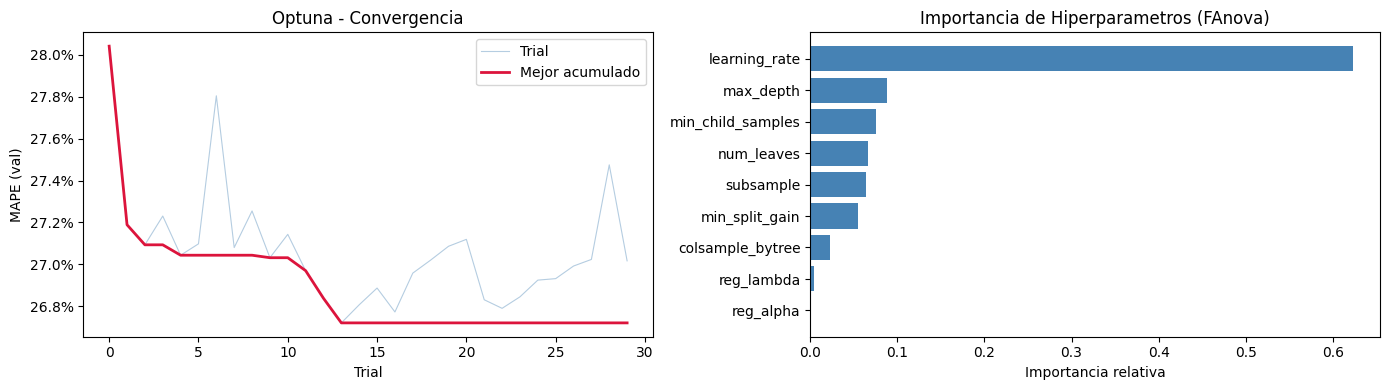

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
trials_df = study.trials_dataframe()

# Curva de convergencia
axes[0].plot(trials_df['number'], trials_df['value'],
             alpha=0.4, color='steelblue', lw=0.8, label='Trial')
axes[0].plot(trials_df['number'], trials_df['value'].cummin(),
             color='crimson', lw=2, label='Mejor acumulado')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('MAPE (val)')
axes[0].set_title('Optuna - Convergencia')
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

# Importancia de hiperparametros (FAnova)
try:
    importance = optuna.importance.get_param_importances(study)
    imp_df = pd.DataFrame(list(importance.items()),
                          columns=['param', 'importance']).sort_values('importance')
    axes[1].barh(imp_df['param'], imp_df['importance'], color='steelblue')
    axes[1].set_xlabel('Importancia relativa')
    axes[1].set_title('Importancia de Hiperparametros (FAnova)')
except Exception as e:
    axes[1].text(0.5, 0.5, f'No disponible: {e}',
                 ha='center', va='center', transform=axes[1].transAxes)

plt.tight_layout()
plt.show()

---
## 5. Entrenamiento KFold con Mejores Parametros

`StratifiedKFold` sobre `price_bin` garantiza que cada fold tenga la misma distribucion de precios.  
Las predicciones de test se promedian sobre los `N_FOLDS` modelos (ensemble de folds).

In [ ]:
# Parametros finales: mejores de Optuna + configuracion fija
FINAL_PARAMS = {
    'objective'     : 'regression',
    'metric'        : 'rmse',
    'verbosity'     : -1,
    'boosting_type' : 'gbdt',
    'seed'          : SEED,
    **best_params_optuna,
}

print('Parametros finales del modelo:')
for k, v in FINAL_PARAMS.items():
    print(f'  {k:<22} = {v}')

Parametros finales del modelo:
  objective              = regression
  metric                 = rmse
  verbosity              = -1
  boosting_type          = gbdt
  seed                   = 42
  num_leaves             = 61
  learning_rate          = 0.014682174547952358
  min_child_samples      = 40
  max_depth              = 12
  subsample              = 0.7698993429926141
  colsample_bytree       = 0.7922474981348614
  reg_alpha              = 0.0035237186030170893
  reg_lambda             = 0.0003318866031537695
  min_split_gain         = 0.005529216003093665


In [ ]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_log_preds  = np.zeros(len(X_train))  # predicciones OOF en escala log
test_log_preds = np.zeros(len(X_test))   # predicciones test (promedio folds)
feat_imp       = np.zeros(len(FEATURE_COLS))
best_iters     = []
fold_mapes     = []

print(f'KFold {N_FOLDS} folds - StratifiedKFold sobre price_bin\n')

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train, strat)):
    X_tr  = X_train.iloc[tr_idx]
    X_val = X_train.iloc[val_idx]
    y_tr  = y_train.iloc[tr_idx]
    y_val = y_train.iloc[val_idx]

    train_ds = lgb.Dataset(X_tr, y_tr,
                           categorical_feature=CAT_COLS, free_raw_data=False)
    val_ds   = lgb.Dataset(X_val, y_val,
                           reference=train_ds, free_raw_data=False)

    model = lgb.train(
        FINAL_PARAMS, train_ds,
        num_boost_round=FINAL_ROUNDS,
        valid_sets=[val_ds],
        callbacks=[
            lgb.early_stopping(EARLY_STOP, verbose=False),
            lgb.log_evaluation(200),
        ],
    )

    oof_log_preds[val_idx]  = model.predict(X_val)
    test_log_preds         += model.predict(X_test) / N_FOLDS
    feat_imp               += model.feature_importance('gain') / N_FOLDS
    best_iters.append(model.best_iteration)

    fold_mape = mean_absolute_percentage_error(
        np.expm1(y_val), np.expm1(oof_log_preds[val_idx])
    )
    fold_mapes.append(fold_mape)
    print(f'  Fold {fold+1}/{N_FOLDS} '
          f'| best_iter={model.best_iteration:4d} '
          f'| MAPE={fold_mape:.4f} ({fold_mape*100:.2f}%)')

print(f'\nMAPE OOF promedio : {np.mean(fold_mapes):.4f} ({np.mean(fold_mapes)*100:.2f}%)')
print(f'MAPE OOF std      : {np.std(fold_mapes):.4f}')
print(f'Best iter promedio: {np.mean(best_iters):.0f}')

KFold 5 folds - StratifiedKFold sobre price_bin

[200]	valid_0's rmse: 0.360022
[400]	valid_0's rmse: 0.351353
[600]	valid_0's rmse: 0.350485
[800]	valid_0's rmse: 0.350104
  Fold 1/5 | best_iter= 820 | MAPE=0.2831 (28.31%)
[200]	valid_0's rmse: 0.349577
[400]	valid_0's rmse: 0.341172
  Fold 2/5 | best_iter= 498 | MAPE=0.2659 (26.59%)
[200]	valid_0's rmse: 0.343028
[400]	valid_0's rmse: 0.333976
[600]	valid_0's rmse: 0.333123
[800]	valid_0's rmse: 0.333117
  Fold 3/5 | best_iter= 747 | MAPE=0.2644 (26.44%)
[200]	valid_0's rmse: 0.344197
[400]	valid_0's rmse: 0.335262
[600]	valid_0's rmse: 0.334244
[800]	valid_0's rmse: 0.333981
  Fold 4/5 | best_iter= 714 | MAPE=0.2584 (25.84%)
[200]	valid_0's rmse: 0.34849
[400]	valid_0's rmse: 0.338822
[600]	valid_0's rmse: 0.33743
  Fold 5/5 | best_iter= 699 | MAPE=0.2630 (26.30%)

MAPE OOF promedio : 0.2670 (26.70%)
MAPE OOF std      : 0.0085
Best iter promedio: 696


---
## 6. Evaluacion OOF

In [ ]:
oof_price_preds = np.expm1(oof_log_preds)
y_train_raw     = np.expm1(y_train.values)

oof_mape     = mean_absolute_percentage_error(y_train_raw, oof_price_preds)
oof_rmse_log = np.sqrt(np.mean((oof_log_preds - y_train.values) ** 2))
oof_mae      = np.mean(np.abs(y_train_raw - oof_price_preds))

print('=== Metricas OOF (train completo) ===')
print(f'  MAPE      : {oof_mape:.4f}  ({oof_mape*100:.2f}%)')
print(f'  RMSE(log) : {oof_rmse_log:.4f}')
print(f'  MAE       : ${oof_mae:,.0f} USD')
print()

# MAPE por bin de precio
oof_df = pd.DataFrame({
    'real'      : y_train_raw,
    'pred'      : oof_price_preds,
    'price_bin' : df_train[STRAT_COL].values,
})
oof_df['ape'] = np.abs(oof_df['real'] - oof_df['pred']) / oof_df['real']

print('MAPE por bin de precio:')
by_bin = oof_df.groupby('price_bin')['ape'].mean().sort_index()
print(by_bin.apply(lambda x: f'{x*100:.2f}%').to_string())

=== Metricas OOF (train completo) ===
  MAPE      : 0.2670  (26.70%)
  RMSE(log) : 0.3389
  MAE       : $120,287 USD

MAPE por bin de precio:
price_bin
Q1     79.42%
Q2     31.78%
Q3     24.40%
Q4     18.87%
Q5     17.08%
Q6     17.64%
Q7     17.87%
Q8     18.67%
Q9     18.24%
Q10    23.00%


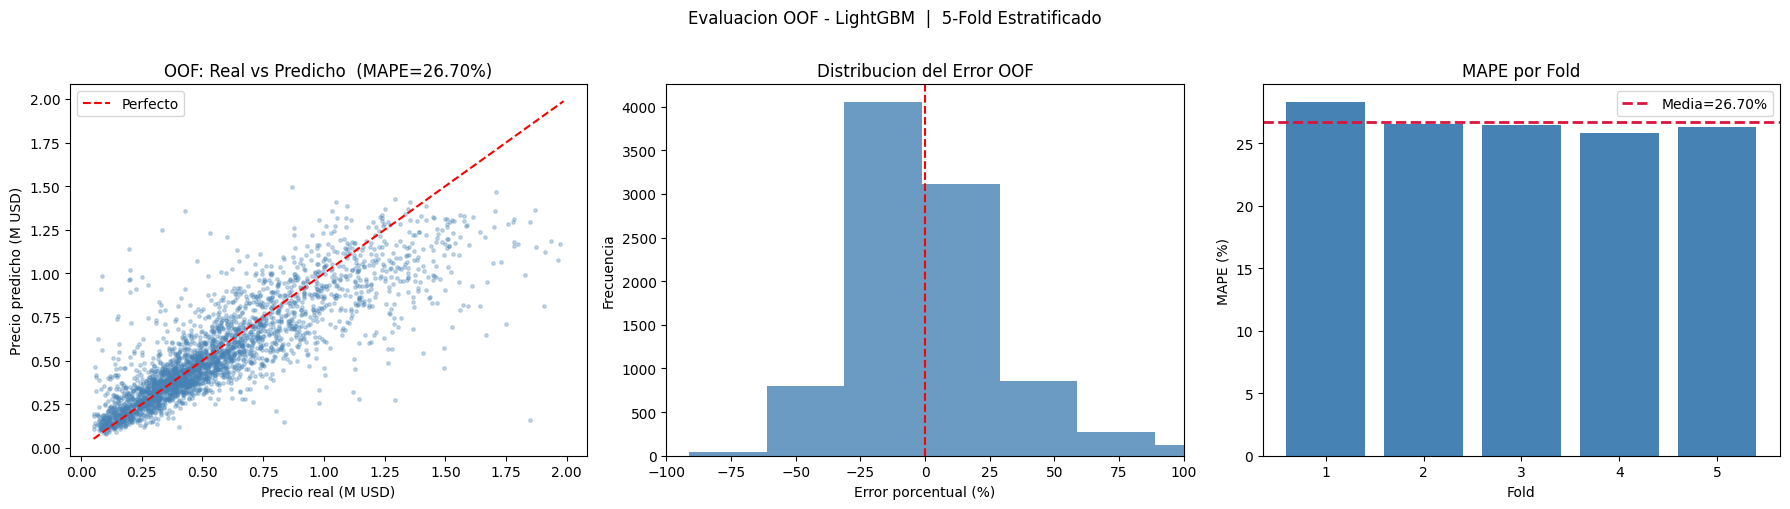

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Real vs Predicho
rng    = np.random.default_rng(SEED)
sample = rng.choice(len(y_train_raw), size=min(3000, len(y_train_raw)), replace=False)
mn     = min(y_train_raw.min(), oof_price_preds.min()) / 1e6
mx     = max(y_train_raw.max(), oof_price_preds.max()) / 1e6

axes[0].scatter(y_train_raw[sample] / 1e6, oof_price_preds[sample] / 1e6,
                alpha=0.3, s=6, color='steelblue')
axes[0].plot([mn, mx], [mn, mx], 'r--', lw=1.5, label='Perfecto')
axes[0].set_xlabel('Precio real (M USD)')
axes[0].set_ylabel('Precio predicho (M USD)')
axes[0].set_title(f'OOF: Real vs Predicho  (MAPE={oof_mape*100:.2f}%)')
axes[0].legend()

# Distribucion del error porcentual
pct_err = (oof_price_preds - y_train_raw) / y_train_raw * 100
axes[1].hist(pct_err, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[1].set_xlabel('Error porcentual (%)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribucion del Error OOF')
axes[1].set_xlim(-100, 100)

# MAPE por fold
axes[2].bar(range(1, N_FOLDS + 1), [m * 100 for m in fold_mapes], color='steelblue')
axes[2].axhline(np.mean(fold_mapes) * 100, color='crimson', lw=2, linestyle='--',
                label=f'Media={np.mean(fold_mapes)*100:.2f}%')
axes[2].set_xlabel('Fold')
axes[2].set_ylabel('MAPE (%)')
axes[2].set_title('MAPE por Fold')
axes[2].legend()

plt.suptitle(f'Evaluacion OOF - LightGBM  |  {N_FOLDS}-Fold Estratificado', y=1.01)
plt.tight_layout()
plt.show()

Top 20 features por importancia (gain promedio sobre folds):
                   feature   importance
          taxAssessedValue 39436.345163
          latest_tax_value 13885.117688
                livingArea  5886.958146
             school_x_area  5339.750190
          log_tax_assessed  3118.045217
        last_listing_price  2685.745231
           log_living_area  1805.329511
effective_tax_rate_implied  1774.069275
           latest_tax_paid  1429.634696
                  zip_freq  1358.524906
              area_x_baths  1307.777803
      dist_to_miami_center   992.242446
            density_x_area   786.026576
       living_area_clipped   729.930882
                 yearBuilt   694.279804
            zip_median_hhi   670.393264
              lotAreaValue   625.701223
         listing_minus_tax   561.786878
      tax_to_listing_ratio   540.989978
                  latitude   526.066700


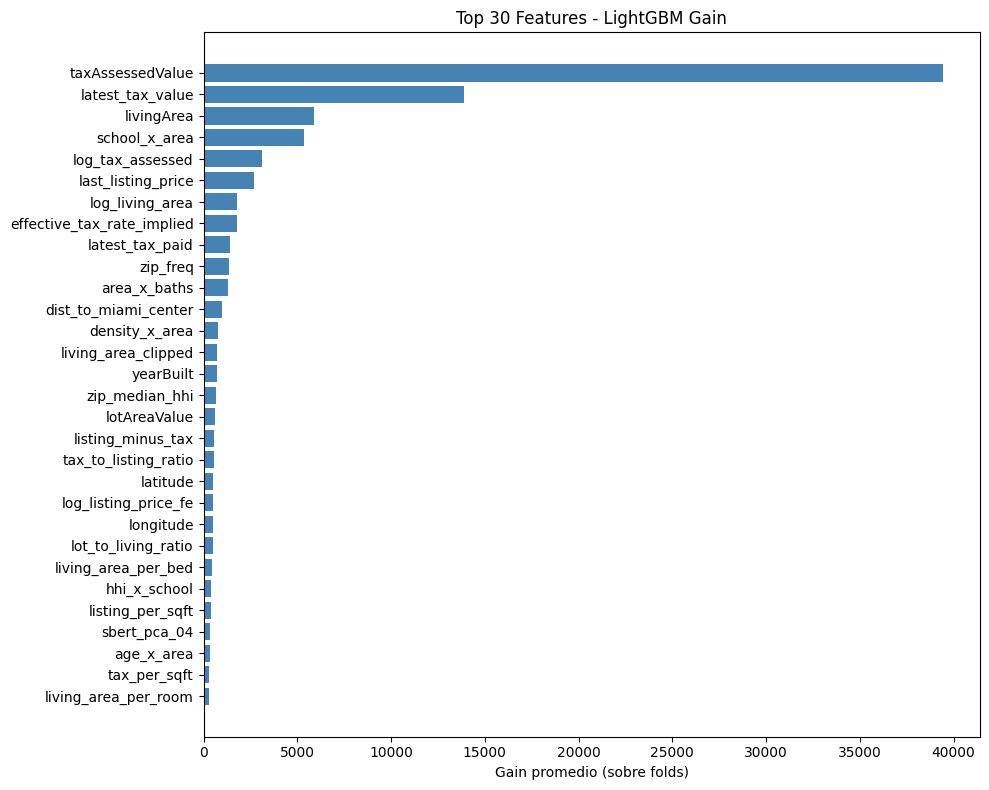

In [ ]:
# Feature importance promedio de todos los folds (gain)
fi_df = pd.DataFrame({
    'feature'   : FEATURE_COLS,
    'importance': feat_imp,
}).sort_values('importance', ascending=False).reset_index(drop=True)

print('Top 20 features por importancia (gain promedio sobre folds):')
print(fi_df.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top30 = fi_df.head(30).sort_values('importance')
ax.barh(top30['feature'], top30['importance'], color='steelblue')
ax.set_xlabel('Gain promedio (sobre folds)')
ax.set_title('Top 30 Features - LightGBM Gain')
plt.tight_layout()
plt.show()

---
## 7. Predicciones de Test

Predicciones de test: 2,368 filas
  Min    : $      91,517
  Media  : $     530,064
  Mediana: $    462,599
  Max    : $   1,480,158

MAPE en test holdout: 0.2614 (26.14%)


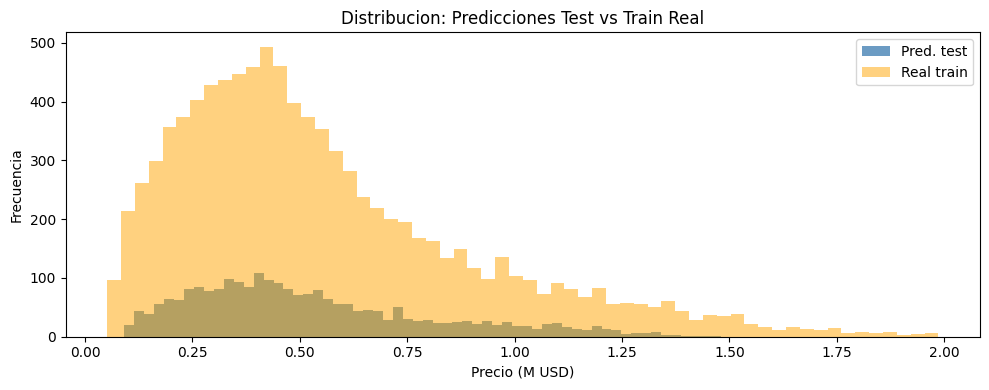

In [ ]:
test_price_preds = np.expm1(test_log_preds)

print(f'Predicciones de test: {len(test_price_preds):,} filas')
print(f'  Min    : ${test_price_preds.min():>12,.0f}')
print(f'  Media  : ${test_price_preds.mean():>12,.0f}')
print(f'  Mediana: ${np.median(test_price_preds):>11,.0f}')
print(f'  Max    : ${test_price_preds.max():>12,.0f}')

if has_test_labels:
    test_mape = mean_absolute_percentage_error(y_test_raw, test_price_preds)
    print(f'\nMAPE en test holdout: {test_mape:.4f} ({test_mape*100:.2f}%)')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(test_price_preds / 1e6, bins=60,
        color='steelblue', edgecolor='none', alpha=0.8, label='Pred. test')
ax.hist(y_train_raw / 1e6, bins=60,
        color='orange', edgecolor='none', alpha=0.5, label='Real train')
ax.set_xlabel('Precio (M USD)')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion: Predicciones Test vs Train Real')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Exportacion de Submission

Formato requerido: `zpid, predicted_price`  
Los precios se exportan en escala real (no logaritmica), redondeados a 2 decimales.

In [ ]:
submission = pd.DataFrame({
    'zpid'            : df_test[ID_COL].values,
    'predicted_price' : test_price_preds.round(2),
})

out_path = SUBMISSIONS / f'{SUBMISSION_NAME}.csv'
submission.to_csv(out_path, index=False)

print(f'Submission guardada en: {out_path}')
print(f'Filas: {len(submission):,}')
print()
print(submission.head(10).to_string(index=False))

Submission guardada en: ..\..\submissions\Pippin_01.04.csv
Filas: 2,368

   zpid  predicted_price
1013708        882889.62
1005786        425560.18
1013543        613920.09
1013040        746402.93
1015034        736977.79
1009857        306450.14
1007992        208934.94
1010061        128280.67
1011158        770509.75
1016558        413818.35


In [ ]:
# Verificacion del formato de submission
check = pd.read_csv(out_path)
assert list(check.columns) == ['zpid', 'predicted_price'], 'Columnas incorrectas'
assert check['predicted_price'].notna().all(), 'Hay NaN en predicciones'
assert (check['predicted_price'] > 0).all(), 'Hay precios negativos o cero'

print('=== Resumen Final ===')
print(f'  Archivo           : {out_path.name}')
print(f'  Filas             : {len(check):,}')
print(f'  MAPE OOF (train)  : {oof_mape*100:.2f}%')
if has_test_labels:
    print(f'  MAPE holdout test : {test_mape*100:.2f}%')
print(f'  Precio mediano    : ${check["predicted_price"].median():,.0f}')
print(f'  Precio minimo     : ${check["predicted_price"].min():,.0f}')
print(f'  Precio maximo     : ${check["predicted_price"].max():,.0f}')
print()
print('Submission OK')

=== Resumen Final ===
  Archivo           : Pippin_01.04.csv
  Filas             : 2,368
  MAPE OOF (train)  : 26.70%
  MAPE holdout test : 26.14%
  Precio mediano    : $462,599
  Precio minimo     : $91,517
  Precio maximo     : $1,480,158

Submission OK


---
## 8.1. Exportacion Train — submissions/test/

Combina las predicciones OOF del train (9 472 filas) con las predicciones del holdout (2 368 filas)
y las guarda en `submissions/test/<SUBMISSION_NAME>.csv` con el mismo formato que la submission oficial.

In [ ]:
TEST_SUBMISSIONS = SUBMISSIONS / 'test'
TEST_SUBMISSIONS.mkdir(parents=True, exist_ok=True)

train_export = pd.DataFrame({
    'zpid'            : df_train[ID_COL].values,
    'predicted_price' : oof_price_preds.round(2),
})

holdout_export = pd.DataFrame({
    'zpid'            : df_test[ID_COL].values,
    'predicted_price' : test_price_preds.round(2),
})

train_full_export = pd.concat([train_export, holdout_export], ignore_index=True)

train_out_path = TEST_SUBMISSIONS / f'{SUBMISSION_NAME}.csv'
train_full_export.to_csv(train_out_path, index=False)

check_train = pd.read_csv(train_out_path)
assert list(check_train.columns) == ['zpid', 'predicted_price'], 'Columnas incorrectas'
assert check_train['predicted_price'].notna().all(), 'Hay NaN en predicciones'
assert (check_train['predicted_price'] > 0).all(), 'Hay precios negativos o cero'

print(f'=== Train Export ===')
print(f'  Archivo        : {train_out_path}')
print(f'  Filas train    : {len(train_export):,}  (OOF)')
print(f'  Filas holdout  : {len(holdout_export):,}')
print(f'  Total          : {len(check_train):,}')
print(f'  Precio mediano : ${check_train["predicted_price"].median():,.0f}')
print(f'  Precio minimo  : ${check_train["predicted_price"].min():,.0f}')
print(f'  Precio maximo  : ${check_train["predicted_price"].max():,.0f}')
print()
print(check_train.head(5).to_string(index=False))

=== Train Export ===
  Archivo        : ..\..\submissions\test\Pippin_01.04.csv
  Filas train    : 9,472  (OOF)
  Filas holdout  : 2,368
  Total          : 11,840
  Precio mediano : $463,703
  Precio minimo  : $72,162
  Precio maximo  : $1,583,023

   zpid  predicted_price
1004447        265801.30
1009466        455772.46
1004565        451195.04
1010282        455113.25
1015118        548171.88


---
## 9. Exportacion para Metamodelo — Test Holdout

Guarda las predicciones sobre el test holdout en `data/meta/test_lgbm.csv` para usarlas
como feature de entrada en el metamodelo (stacking).

Las predicciones se guardan en **escala logaritmica** (`log_price`) para que el metamodelo
opere en la misma escala que el target de entrenamiento.

In [ ]:
META_DIR = ROOT / 'data' / 'meta'
META_DIR.mkdir(parents=True, exist_ok=True)

meta_test = pd.DataFrame({
    'zpid'      : df_test[ID_COL].values,
    'lgbm_pred' : test_log_preds.round(6),
})

meta_test_path = META_DIR / 'test_sent_lgbm.csv'
meta_test.to_csv(meta_test_path, index=False)

print(f'Exportado: {meta_test_path}')
print(f'Filas: {len(meta_test):,}')
print(meta_test.head())

Exportado: ..\..\data\meta\test_sent_lgbm.csv
Filas: 2,368
      zpid  lgbm_pred
0  1013708  13.690957
1  1005786  12.961164
2  1013543  13.327622
3  1013040  13.523022
4  1015034  13.510314


---
## 10. Predicciones sobre competition_test_fe.parquet

Carga el parquet del conjunto de competencia real (`competition_test_fe.parquet`), aplica las mismas
transformaciones de tipo que al train/test, y genera predicciones promediando los `N_FOLDS` modelos.

> Los modelos del KFold ya estan entrenados en memoria. Si se reinicia el kernel,
> hay que volver a ejecutar las celdas anteriores antes de correr esta seccion.

In [ ]:
SUBMISSION_FE_PATH = DATA_DIR / 'competition_test_fe_sent.parquet'

df_submission = pd.read_parquet(SUBMISSION_FE_PATH)
print(f'df_competition_test_fe shape: {df_submission.shape}')
print(f'Columnas presentes  : {len(df_submission.columns)}')
print(f'zpid sample         : {df_submission[ID_COL].head(3).tolist()}')

# Verificar que tiene todas las features esperadas
missing_cols = [c for c in FEATURE_COLS if c not in df_submission.columns]
if missing_cols:
    print(f'WARN - Features faltantes ({len(missing_cols)}): {missing_cols}')
else:
    print(f'Features OK - todas las {len(FEATURE_COLS)} columnas presentes')

df_competition_test_fe shape: (5038, 248)
Columnas presentes  : 248
zpid sample         : [1009018, 1001436, 1010988]
Features OK - todas las 246 columnas presentes


In [ ]:
# Aplicar las mismas transformaciones de tipo que al train/test
for col in INT64_NULLABLE:
    if col in df_submission.columns:
        df_submission[col] = df_submission[col].astype(float)
for col in CAT_COLS:
    if col in df_submission.columns:
        df_submission[col] = df_submission[col].astype('category')

X_submission = df_submission[FEATURE_COLS].copy()
print(f'X_submission : {X_submission.shape}')

X_submission : (5038, 246)


In [ ]:
# Regenerar predicciones promediando los N_FOLDS modelos
# Requiere que los modelos esten en memoria (ejecutar las celdas del KFold antes)
skf2 = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

sub_log_preds = np.zeros(len(X_submission))
models_list   = []  # guarda cada modelo del fold

print(f'Reentrenando {N_FOLDS} folds para generar predicciones de submission...\n')

for fold, (tr_idx, val_idx) in enumerate(skf2.split(X_train, strat)):
    X_tr  = X_train.iloc[tr_idx]
    X_val = X_train.iloc[val_idx]
    y_tr  = y_train.iloc[tr_idx]
    y_val = y_train.iloc[val_idx]

    train_ds = lgb.Dataset(X_tr, y_tr,
                           categorical_feature=CAT_COLS, free_raw_data=False)
    val_ds   = lgb.Dataset(X_val, y_val,
                           reference=train_ds, free_raw_data=False)

    model_sub = lgb.train(
        FINAL_PARAMS, train_ds,
        num_boost_round=FINAL_ROUNDS,
        valid_sets=[val_ds],
        callbacks=[
            lgb.early_stopping(EARLY_STOP, verbose=False),
            lgb.log_evaluation(-1),
        ],
    )

    sub_log_preds += model_sub.predict(X_submission) / N_FOLDS
    models_list.append(model_sub)

    fold_mape = mean_absolute_percentage_error(
        np.expm1(y_val), np.expm1(model_sub.predict(X_val))
    )
    print(f'  Fold {fold+1}/{N_FOLDS} | best_iter={model_sub.best_iteration:4d} | MAPE_val={fold_mape:.4f}')

sub_price_preds = np.expm1(sub_log_preds)

print(f'\nPredicciones de submission: {len(sub_price_preds):,} filas')
print(f'  Min    : ${sub_price_preds.min():>12,.0f}')
print(f'  Media  : ${sub_price_preds.mean():>12,.0f}')
print(f'  Mediana: ${np.median(sub_price_preds):>11,.0f}')
print(f'  Max    : ${sub_price_preds.max():>12,.0f}')

Reentrenando 5 folds para generar predicciones de submission...

  Fold 1/5 | best_iter= 820 | MAPE_val=0.2831
  Fold 2/5 | best_iter= 498 | MAPE_val=0.2659
  Fold 3/5 | best_iter= 747 | MAPE_val=0.2644
  Fold 4/5 | best_iter= 714 | MAPE_val=0.2584
  Fold 5/5 | best_iter= 699 | MAPE_val=0.2630

Predicciones de submission: 5,038 filas
  Min    : $      87,947
  Media  : $     533,212
  Mediana: $    470,399
  Max    : $   1,520,009


In [ ]:
submission_final = pd.DataFrame({
    'zpid'            : df_submission[ID_COL].values,
    'predicted_price' : sub_price_preds.round(2),
})

sub_out_path = SUBMISSIONS / f'{SUBMISSION_NAME}.csv'
submission_final.to_csv(sub_out_path, index=False)

# Verificacion
check_sub = pd.read_csv(sub_out_path)
assert list(check_sub.columns) == ['zpid', 'predicted_price'], 'Columnas incorrectas'
assert check_sub['predicted_price'].notna().all(), 'Hay NaN en predicciones'
assert (check_sub['predicted_price'] > 0).all(), 'Hay precios negativos o cero'

print(f'=== Submission Final ===')
print(f'  Archivo        : {sub_out_path.name}')
print(f'  Filas          : {len(check_sub):,}')
print(f'  Precio mediano : ${check_sub["predicted_price"].median():,.0f}')
print(f'  Precio minimo  : ${check_sub["predicted_price"].min():,.0f}')
print(f'  Precio maximo  : ${check_sub["predicted_price"].max():,.0f}')
print()
print('Submission OK')
print()
print(check_sub.head(10).to_string(index=False))

=== Submission Final ===
  Archivo        : Pippin_01.04.csv
  Filas          : 5,038
  Precio mediano : $470,399
  Precio minimo  : $87,947
  Precio maximo  : $1,520,009

Submission OK

   zpid  predicted_price
1009018        465061.04
1001436        672478.86
1010988        510182.71
1002184        269350.65
1015717        319746.79
1001346        599202.11
1006728        137525.43
1002644        277204.10
1009198        791827.25
1008339        504836.78


---
## 11. Exportacion para Metamodelo — Competition Test

Guarda las predicciones sobre el conjunto de competencia en `data/meta/comp_lgbm.csv`
para usarlas como feature de entrada en el metamodelo (stacking).

Las predicciones se guardan en **escala logaritmica** (`log_price`).

In [ ]:
meta_comp = pd.DataFrame({
    'zpid'      : df_submission[ID_COL].values,
    'lgbm_pred' : sub_log_preds.round(6),
})

meta_comp_path = META_DIR / 'comp_sent_lgbm.csv'
meta_comp.to_csv(meta_comp_path, index=False)

print(f'Exportado: {meta_comp_path}')
print(f'Filas: {len(meta_comp):,}')
print(meta_comp.head())

Exportado: ..\..\data\meta\comp_sent_lgbm.csv
Filas: 5,038
      zpid  lgbm_pred
0  1009018  13.049926
1  1001436  13.418727
2  1010988  13.142526
3  1002184  12.503773
4  1015717  12.675288
